In [1]:
import sys
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt

# Ensure the repository root (parent of the notebooks folder) is on sys.path
# so local packages like 'preprocessing' can be imported.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from preprocessing.load_datasets import load_ucsd_ped2

DATASET_ROOT = "../data/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset.v1p2"

train_videos, test_videos = load_ucsd_ped2(DATASET_ROOT)

print("Train video folders:", len(train_videos))
print("Test video folders:", len(test_videos))
print("Example train folder:", train_videos[0])
print("Example test folder:", test_videos[0])

Train video folders: 16
Test video folders: 24
Example train folder: ../data/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset.v1p2\UCSDped2\Train\Train001
Example test folder: ../data/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset.v1p2\UCSDped2\Test\Test001


In [ ]:
def load_video_frames(folder_path):
    frame_paths = sorted(
        glob.glob(folder_path + "/*.tif") +   # we are matching both .tif and .bmp files and sorting them 
        glob.glob(folder_path + "/*.bmp")
    )
    return frame_paths


In [3]:
sample_train_folder = train_videos[1]
frames = load_video_frames(sample_train_folder)

print("Number of frames:", len(frames))
print("First frame:", frames[1])


Number of frames: 150
First frame: ../data/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset.v1p2\UCSDped2\Train\Train002\002.tif


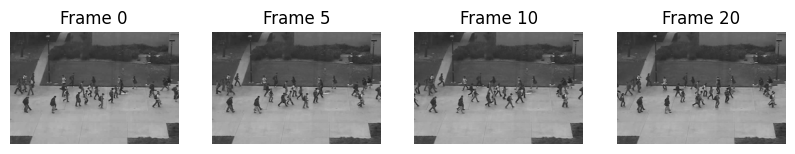

In [4]:
plt.figure(figsize=(10,4))

for i, frame_idx in enumerate([0, 5, 10, 20]):
    img = cv2.imread(frames[frame_idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(f"Frame {frame_idx}")
    plt.axis("off")

plt.show()


In [5]:
img1 = cv2.imread(frames[0])
img = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

h, w, c = img.shape
print("Frame Width:", w)
print("Frame Height:", h)
print("Channels:", c)    # RGB has 3 channels
print("FPS: 10 (fixed for UCSD Ped2 dataset)")


Frame Width: 360
Frame Height: 240
Channels: 3
FPS: 10 (fixed for UCSD Ped2 dataset)


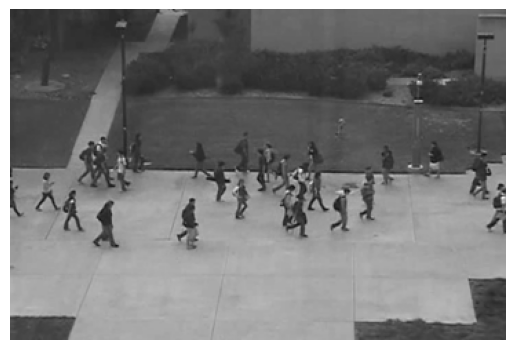

In [6]:
import time
from IPython.display import clear_output

for f in frames[:50]:  # show first 50 frames
    img = cv2.imread(f)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    plt.axis("off")  # hide axes
    clear_output(wait=True)   # clear previous frame output before showing new frame
    plt.show()
    time.sleep(0.1)   # 0.1 sec = 10 FPS


In [7]:
sample_test_folder = test_videos[0]
test_frames = load_video_frames(sample_test_folder)

print("Test folder:", sample_test_folder)
print("Num frames:", len(test_frames))


Test folder: ../data/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset.v1p2\UCSDped2\Test\Test001
Num frames: 180


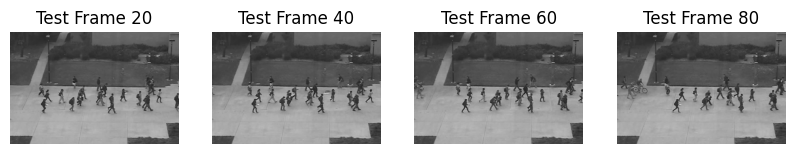

In [ ]:
plt.figure(figsize=(10,4))

for i, frame_idx in enumerate([20, 40, 60, 80]):
    img = cv2.imread(test_frames[frame_idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 4, i+1)   # 1 row, 4 columns, position i+1
    plt.imshow(img)
    plt.title(f"Test Frame {frame_idx}")
    plt.axis("off")

plt.show()
